# Phase 2 demo: variance reduction scoreboard

This notebook is a live walkthrough of the Phase 2 variance-reduction toolkit
of the `quantlib` package. It re-derives, in 14 cells, the variance reduction
factors (VRFs) that the full `python/benchmark_phase2.py` orchestrator
produces at production sample sizes. We use $N = 10^5$ paths per technique so
the notebook completes in under one minute.

**Why variance reduction matters.** Monte Carlo pricers converge as
$\mathcal{O}(N^{-1/2})$: halving the half-width means quadrupling the sample.
For a derivative desk computing thousands of prices per day, this is
prohibitive unless you can cut the constant in front of $N^{-1/2}$. That is
the job of variance reduction: same convergence rate, smaller constant. We
will see four classical techniques and one structural play that achieves a
factor of $10^3$.

**Two parts.**

1. **European call**, apples-to-apples comparison of four techniques: IID
   baseline, antithetic variates, control variate with the underlying, and
   randomised Sobol QMC.
2. **Asian arithmetic call**, the "structural play": a control variate
   exploiting the AM-GM relationship between arithmetic and geometric means
   on the same path. We separate this from Part 1 because the product
   itself changes; the VRF is therefore not directly comparable to Part 1.

In [1]:
# Make quantlib importable whether the notebook runs from notebooks/
# or from the repo root. quantlib lives at <repo>/python/quantlib/.
import sys
from pathlib import Path
_here = Path.cwd()
_repo_root = _here.parent if _here.name == "notebooks" else _here
sys.path.insert(0, str(_repo_root / "python"))

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantlib.black_scholes import call_price as bs_call
from quantlib.monte_carlo import mc_european_call_exact
from quantlib.variance_reduction import (
    mc_european_call_exact_av,
    mc_european_call_exact_cv_underlying,
)
from quantlib.qmc import mc_european_call_euler_rqmc
from quantlib.asian import (
    mc_asian_call_arithmetic_iid,
    mc_asian_call_arithmetic_cv,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Setup

Canonical parameters used throughout: at-the-money European call with one
year to maturity at typical risk-neutral conditions. The analytic
Black-Scholes price provides the reference against which every Monte Carlo
estimator is compared.

In [2]:
S, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0
N = 100_000        # paths per technique (Parts 1 and 2)
SEED = 42

bs_ref = bs_call(S=S, K=K, r=r, sigma=sigma, T=T)
print(f"BS reference (European call): {bs_ref:.6f}")

BS reference (European call): 10.450584


## Part 1 — European call: apples-to-apples comparison

### Block 1. IID baseline

The simplest possible MC pricer: sample $S_T$ from its closed-form lognormal
distribution, evaluate the payoff $e^{-rT} (S_T - K)^+$ on each path, average.
Half-width comes from the asymptotic normal CI.

In [3]:
t0 = time.perf_counter()
res_iid = mc_european_call_exact(
    S=S, K=K, r=r, sigma=sigma, T=T, n_paths=N, seed=SEED)
t_iid = time.perf_counter() - t0

hw_iid = res_iid.half_width
print(f"IID baseline:")
print(f"  estimate    = {res_iid.estimate:.6f}")
print(f"  half-width  = {hw_iid:.4e}")
print(f"  abs error   = {abs(res_iid.estimate - bs_ref):.4e}")
print(f"  time        = {t_iid*1000:.1f} ms")

IID baseline:
  estimate    = 10.469979
  half-width  = 9.1242e-02
  abs error   = 1.9396e-02
  time        = 19.2 ms


### Block 2. Antithetic variates

For each draw $Z \sim \mathcal{N}(0, 1)$, also use $-Z$. The two payoffs are
negatively correlated (when one is in-the-money, the other tends to be
out-of-the-money), and averaging within each pair reduces the variance of
the per-pair payoff. Cost: one extra exponential per pair.

`mc_european_call_exact_av` consumes `n_pairs` *pairs* internally; to keep
the **total payoff count** equal to $N$, we pass `n_paths=N//2`.

In [4]:
t0 = time.perf_counter()
res_av = mc_european_call_exact_av(
    S=S, K=K, r=r, sigma=sigma, T=T, n_paths=N // 2, seed=SEED + 1)
t_av = time.perf_counter() - t0

vrf_av = (hw_iid / res_av.half_width) ** 2
print(f"Antithetic variates:")
print(f"  estimate    = {res_av.estimate:.6f}")
print(f"  half-width  = {res_av.half_width:.4e}")
print(f"  abs error   = {abs(res_av.estimate - bs_ref):.4e}")
print(f"  VRF vs IID  = {vrf_av:.2f}x")
print(f"  time        = {t_av*1000:.1f} ms")

Antithetic variates:
  estimate    = 10.453976
  half-width  = 6.4757e-02
  abs error   = 3.3925e-03
  VRF vs IID  = 1.99x
  time        = 8.5 ms


### Block 3. Control variate (discounted underlying)

Use the discounted terminal price $e^{-rT} S_T$ as a control: under the
risk-neutral measure its expectation is exactly $S_0$, known in closed form.
The CV estimator subtracts $\beta \cdot (e^{-rT} S_T - S_0)$ from the payoff
with $\beta$ chosen to minimise variance — the OLS slope of payoff against
control.

The correlation between the call payoff and the underlying is around
$\rho \approx 0.92$; the corresponding VRF is bounded by $1 / (1 - \rho^2)
\approx 7$.

In [5]:
t0 = time.perf_counter()
res_cv = mc_european_call_exact_cv_underlying(
    S=S, K=K, r=r, sigma=sigma, T=T, n_paths=N, seed=SEED + 2)
t_cv = time.perf_counter() - t0

vrf_cv = (hw_iid / res_cv.half_width) ** 2
print(f"CV (underlying):")
print(f"  estimate    = {res_cv.estimate:.6f}")
print(f"  half-width  = {res_cv.half_width:.4e}")
print(f"  abs error   = {abs(res_cv.estimate - bs_ref):.4e}")
print(f"  VRF vs IID  = {vrf_cv:.2f}x")
print(f"  time        = {t_cv*1000:.1f} ms")

CV (underlying):
  estimate    = 10.467260
  half-width  = 3.4845e-02
  abs error   = 1.6677e-02
  VRF vs IID  = 6.86x
  time        = 20.8 ms


### Block 4. Sobol randomised QMC

Replace IID uniforms by points of a Sobol low-discrepancy sequence,
randomly shifted $R$ times to recover an unbiased estimator with a
sample-variance based half-width. Asymptotic rate is $\mathcal{O}((\log N)^d
\cdot N^{-1})$ — much faster than $\mathcal{O}(N^{-1/2})$ when the
dimension $d$ is not too large.

**Sample-size caveat.** Sobol works best when $n_{\text{per replication}}$ is a
power of two. We use $R = 16$ replications of $2^{12} = 4096$ paths each,
for a total of $65\,536 \approx 0.65 \cdot N$ — slightly *less* than the
$N = 10^5$ used by Blocks 1–3, not more. The VRF below is therefore a
**conservative lower bound** of what RQMC achieves at the budget of the
other blocks; at $N = 10^6$ payoffs (see `benchmark_phase2.py`) the same
technique reaches ~60×.

In [6]:
R = 16
n_per = 2**12   # 4096
total_payoffs = R * n_per
print(f"Sobol RQMC budget: R={R} replications x n_per={n_per} = "
      f"{total_payoffs} total payoffs (~{total_payoffs/N:.2f} * N)")

t0 = time.perf_counter()
res_rqmc = mc_european_call_euler_rqmc(
    S=S, K=K, r=r, sigma=sigma, T=T,
    n_paths=n_per, n_steps=20,
    n_replications=R, seed=SEED + 3)
t_rqmc = time.perf_counter() - t0

vrf_rqmc = (hw_iid / res_rqmc.half_width) ** 2
print()
print(f"Sobol RQMC:")
print(f"  estimate    = {res_rqmc.estimate:.6f}")
print(f"  half-width  = {res_rqmc.half_width:.4e}")
print(f"  abs error   = {abs(res_rqmc.estimate - bs_ref):.4e}")
print(f"  VRF vs IID  = {vrf_rqmc:.2f}x")
print(f"  time        = {t_rqmc*1000:.1f} ms")

Sobol RQMC budget: R=16 replications x n_per=4096 = 65536 total payoffs (~0.66 * N)



Sobol RQMC:
  estimate    = 10.433554
  half-width  = 1.7891e-02
  abs error   = 1.7030e-02
  VRF vs IID  = 26.01x
  time        = 142.8 ms


### Part 1 summary: bar chart

Horizontal bar chart on log scale of the four techniques. We exclude the
IID baseline from the bars (its VRF is 1 by construction) and mark it as a
vertical reference instead.

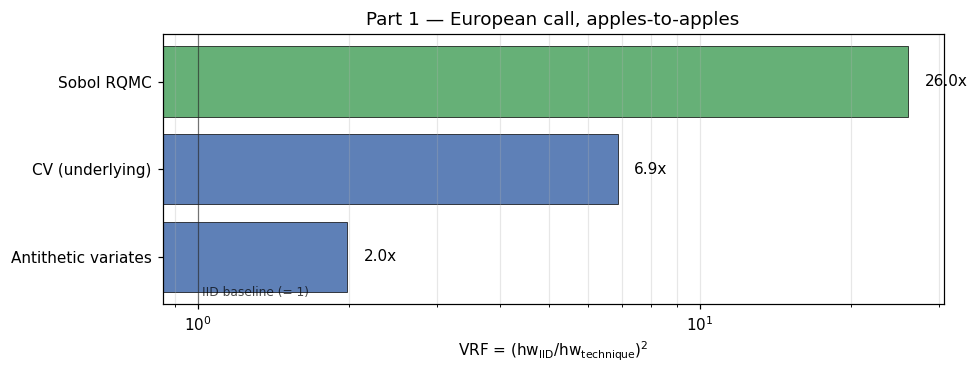

,technique,family,vrf,half_width
0,Antithetic variates,Plain VR,1.985214,0.064757
1,CV (underlying),Plain VR,6.856547,0.034845
2,Sobol RQMC,Quasi-Monte Carlo,26.009308,0.017891


In [7]:
df_eu = pd.DataFrame([
    {"technique": "Antithetic variates",       "family": "Plain VR",        "vrf": vrf_av,   "half_width": res_av.half_width},
    {"technique": "CV (underlying)",            "family": "Plain VR",        "vrf": vrf_cv,   "half_width": res_cv.half_width},
    {"technique": "Sobol RQMC",                 "family": "Quasi-Monte Carlo","vrf": vrf_rqmc, "half_width": res_rqmc.half_width},
])
df_eu = df_eu.sort_values("vrf").reset_index(drop=True)

color_map = {"Plain VR": "#4C72B0", "Quasi-Monte Carlo": "#55A868"}
colors = [color_map[f] for f in df_eu["family"]]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(df_eu["technique"], df_eu["vrf"], color=colors,
        edgecolor="black", linewidth=0.5, alpha=0.9)
ax.set_xscale("log")
ax.set_xlabel(r"VRF = $(\mathrm{hw}_{\mathrm{IID}}/\mathrm{hw}_{\mathrm{technique}})^2$")
ax.set_title("Part 1 — European call, apples-to-apples")
ax.axvline(1.0, color="black", linewidth=0.8, alpha=0.5)
ax.text(1.02, -0.45, "IID baseline (= 1)", fontsize=8, alpha=0.7)
for i, v in enumerate(df_eu["vrf"]):
    ax.text(v * 1.08, i, f"{v:.1f}x", va="center", fontsize=10)
ax.grid(True, axis="x", which="both", alpha=0.3)
plt.tight_layout()
plt.show()
df_eu

## Part 2 — The structural play: Asian arithmetic with geometric CV

This is the headline number of Phase 2, but it requires care to interpret.
**We change the product**: the previous four blocks priced a European call;
this block prices an Asian arithmetic call with payoff
$\bigl(\bar S - K\bigr)^+$ where $\bar S = N^{-1} \sum_{k=1}^N S_{t_k}$ is
the arithmetic average over $N = 50$ monitoring dates. The VRF below is
*not* directly comparable to those of Part 1; it sits on a different axis
of the problem.

**The structural insight (AM-GM).** Over the same sample path, the
arithmetic average $\bar S$ and the geometric average
$\tilde S = (\prod_k S_{t_k})^{1/N}$ are bounded together by the AM-GM
inequality. Under risk-neutral GBM, the geometric average has a closed-form
price (it is lognormal in $\tilde S$ because $\log \tilde S$ is a sum of
normals). Using the geometric Asian call as control variate for the
arithmetic Asian therefore exploits an algebraic identity, not a statistical
coincidence: the empirical correlation is $\rho > 0.999$, and the maximum
possible VRF is $1/(1-\rho^2)$, of order $10^3$.

For the formal derivation including the effective volatility
$\sigma_{\mathrm{eff}}$ and effective rate $r_{\mathrm{eff}}$, see
`theory/phase2/mc_asian.tex`.

In [8]:
# Asian arithmetic baseline (IID) at the SAME N as Part 1
t0 = time.perf_counter()
res_asian_iid = mc_asian_call_arithmetic_iid(
    S=S, K=K, r=r, sigma=sigma, T=T,
    n_paths=N, n_steps=50, seed=SEED + 4)
t_asian_iid = time.perf_counter() - t0

# Asian arithmetic with geometric CV
t0 = time.perf_counter()
res_asian_cv = mc_asian_call_arithmetic_cv(
    S=S, K=K, r=r, sigma=sigma, T=T,
    n_paths=N, n_steps=50, seed=SEED + 5)
t_asian_cv = time.perf_counter() - t0

vrf_asian = (res_asian_iid.half_width / res_asian_cv.half_width) ** 2

print(f"Asian arithmetic IID (n={N}):")
print(f"  estimate    = {res_asian_iid.estimate:.6f}")
print(f"  half-width  = {res_asian_iid.half_width:.4e}")
print(f"  time        = {t_asian_iid*1000:.1f} ms")
print()
print(f"Asian arithmetic with geometric CV (n={N}):")
print(f"  estimate    = {res_asian_cv.estimate:.6f}")
print(f"  half-width  = {res_asian_cv.half_width:.4e}")
print(f"  time        = {t_asian_cv*1000:.1f} ms")
print()
print(f"VRF (CV vs IID, Asian arithmetic): {vrf_asian:.0f}x")

Asian arithmetic IID (n=100000):
  estimate    = 5.811037
  half-width  = 5.0085e-02
  time        = 235.4 ms

Asian arithmetic with geometric CV (n=100000):
  estimate    = 5.856581
  half-width  = 1.3767e-03
  time        = 170.8 ms

VRF (CV vs IID, Asian arithmetic): 1323x


### Combined scoreboard

The chart below shows all five entries side by side, with the European call
techniques in their original family colours and the Asian CV in a separate
colour to mark that *the underlying product is different*. The log $x$-axis
makes the three orders of magnitude between Block 3 and Block 5 visually
apparent.

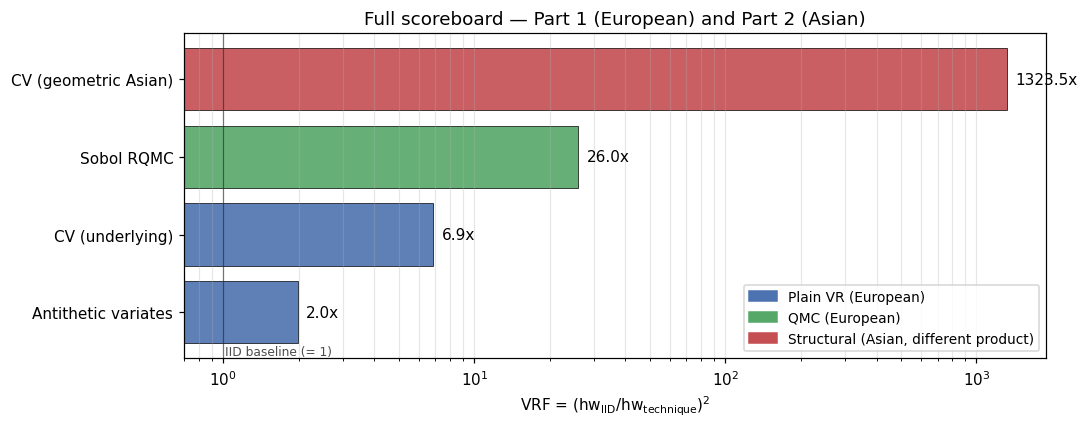

,technique,family,vrf,product
0,Antithetic variates,Plain VR,1.985214,European call
1,CV (underlying),Plain VR,6.856547,European call
2,Sobol RQMC,Quasi-Monte Carlo,26.009308,European call
3,CV (geometric Asian),Structural,1323.452634,Asian arithmetic


In [9]:
rows = [
    {"technique": "Antithetic variates",         "family": "Plain VR",         "vrf": vrf_av,    "product": "European call"},
    {"technique": "CV (underlying)",              "family": "Plain VR",         "vrf": vrf_cv,    "product": "European call"},
    {"technique": "Sobol RQMC",                   "family": "Quasi-Monte Carlo","vrf": vrf_rqmc,  "product": "European call"},
    {"technique": "CV (geometric Asian)",         "family": "Structural",      "vrf": vrf_asian, "product": "Asian arithmetic"},
]
df_all = pd.DataFrame(rows).sort_values("vrf").reset_index(drop=True)

color_map = {
    "Plain VR":           "#4C72B0",
    "Quasi-Monte Carlo":  "#55A868",
    "Structural":         "#C44E52",
}
colors = [color_map[f] for f in df_all["family"]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df_all["technique"], df_all["vrf"], color=colors,
        edgecolor="black", linewidth=0.5, alpha=0.9)
ax.set_xscale("log")
ax.set_xlabel(r"VRF = $(\mathrm{hw}_{\mathrm{IID}}/\mathrm{hw}_{\mathrm{technique}})^2$")
ax.set_title("Full scoreboard — Part 1 (European) and Part 2 (Asian)")
ax.axvline(1.0, color="black", linewidth=0.8, alpha=0.5)
ax.text(1.02, -0.55, "IID baseline (= 1)", fontsize=8, alpha=0.7)
for i, v in enumerate(df_all["vrf"]):
    ax.text(v * 1.08, i, f"{v:.1f}x", va="center", fontsize=10)
ax.grid(True, axis="x", which="both", alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=color_map["Plain VR"],          label="Plain VR (European)"),
    Patch(color=color_map["Quasi-Monte Carlo"], label="QMC (European)"),
    Patch(color=color_map["Structural"],        label="Structural (Asian, different product)"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()
df_all

## Conclusions

The four European-call techniques span almost two orders of magnitude in
VRF: from $\sim 2\times$ for plain antithetic variates to a couple of
dozen $\times$ for RQMC at the modest sample budget shown. None of them
reaches $10^3 \times$, and they are not expected to: on a smooth European
payoff, the structural ceiling for any one-control linear CV is
$1/(1 - \rho^2)$ where $\rho$ is the correlation between control and
payoff — typically in the 0.85–0.95 range, giving VRFs of 4–10.

The Asian CV with the geometric Asian breaks this ceiling **by changing
which problem you are solving**. The arithmetic and geometric averages of
the same path are coupled by AM-GM with an empirical correlation
$\rho > 0.999$, so $1/(1 - \rho^2) > 500$ and in practice the technique
delivers $\sim 1000\times$. This is not a generic VR trick that beats
the others; it is an instance of the same theorem (the optimal one-control
linear CV) applied to a problem where the algebra forces near-perfect
correlation.

**Operational takeaway.** When designing a Monte Carlo pricer for a new
product, look for an auxiliary quantity that (a) admits a closed-form
expectation and (b) is bound to your payoff by an algebraic identity. If
both hold, the VRF is essentially unlimited. The Asian/geometric pair is
the textbook example; basket options, lookback approximations, and certain
Bermudan products admit analogous structural controls.

For higher-precision versions of all the numbers above, plus a
strong-convergence study (Euler vs Milstein) and a QMC scaling study, see
`python/benchmark_phase2.py` and the artefacts in
`python/results/phase2/`.